# Cataloguing Seismic Events


A tutorial by Simon Ramirez

This notebook details the process of creating PPSD plots.

## 0. Imports

In [ ]:
# For Configuration File
import yaml
from pathlib import Path
import importlib

config_path = ### Input the path to your config file ###
with open(config_path, "r") as f:
    config = yaml.safe_load(f)


name = config["name"]
seismic_path = config["seismic_data_path"]
seismic_data = Path(config['seismic_data_path'])
align_module = config['align_module']
process_module = config['process_module']


# obspy GitHub:
# https://github.com/obspy/obspy
from obspy import UTCDateTime as UTC

# seismic-data-quality GitHub: 
# https://github.com/Ramirezs873/seismic-data-quality
spec1 = importlib.util.spec_from_file_location("process", process_module)
process = importlib.util.module_from_spec(spec1)
spec1.loader.exec_module(process)

# seismic-sensor-anlysis GitHub:
# https://github.com/Ramirezs873/seismic-sensor-analysis
spec2 = importlib.util.spec_from_file_location("align", align_module)
align = importlib.util.module_from_spec(spec2)
spec2.loader.exec_module(align)



## 1. Gather Station Information

event_catalogue() has multiple purposes. It can be used to lookup and catalogue event information for specific sensors and it can also be used to create an ObsPy inventory. 

The first ([0]) output of the function is event information and the second ([1]) is the inventory. 

The event information has the option to be saved as a csv file. The inventory is saved as a xml file. If these files are saved locally, then the function reads those files instead.

There are a few options to specify event criteria:
* event_t0 & event_t1. In UTC. If None then the entire sensor timespan is used.
* radius. Max search radius degrees centered around the station. If None then there is no maximum radius.
* min_mag. The minimum magnitude (Mw) of events to gather. If None then all magnitudes are gathered.
* max_depth. The maximum depth in km to search for events. If None then all depths are considered.

There is also the option to change the title and projection of the map. See obspy.core.event.catalog.Catalog.plot for projection options.


File not found. Downloading data
Saved to: C:\Users\simon\Desktop\UTAS\2026 Sem 1\KAA308 CWA Appraisal Research\GitHub\seismic-data-quality\Seismic Files\station_data_CWA81.xml


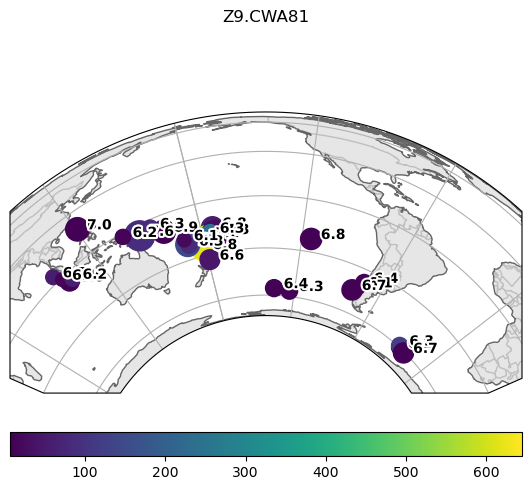

In [7]:
catalog = process.event_catalogue(client ="AUSPASS", 
                                  network = 'Z9', 
                                  station = 'CWA81', 
                                  event_t0 = UTC(2022, 6, 1, 0, 0,0),
                                  event_t1 = UTC(2023, 1, 1, 0, 0, 0),
                                  radius = 85,
                                  min_mag = 6,
                                  max_depth = None,
                                  title = 'CWA81',
                                  user='Z9', password='peach25',
                                  config = config,
                                  csv = False,
                                  map = True, 
                                  projection = 'local')

In [11]:
catalog

([defaultdict(list,
              {'Z9.CWA81': {'latitude': -66.319,
                'longitude': 110.9434,
                't_start': 2022-01-10T02:15:44.410000Z,
                't_end': 2023-12-08T08:25:43.220000Z}}),
  defaultdict(list,
              {'Z9.CWA81': 33 Event(s) in Catalog:
2022-12-28T16:34:24.213000Z | -21.234, +171.321 | 6.16 Mw | manual
2022-12-04T19:24:17.429000Z | -15.480, -173.198 | 6.83 Mww | manual
...
2022-07-11T21:10:51.218000Z | -18.188, +168.968 | 6.1  Mw | manual
2022-06-04T13:07:27.240000Z | -17.972, -175.102 | 6.31 Mw | manual
To see all events call 'print(CatalogObject.__str__(print_all=True))'})],
 Inventory created at 2026-05-21T11:17:52.762172Z
	Sending institution: SeisComP (ANU-RSES)
	Contains:
		Networks (1):
			Z9
		Stations (1):
			Z9.CWA81 (Law Dome Route near D03)
		Channels (3):
			Z9.CWA81..HHZ, Z9.CWA81..HHN, Z9.CWA81..HHE)